# Attention-Based Earthquake Catalog Continuation

This notebook implements a Marked Temporal Point Process (MTPP) Transformer using TensorFlow/Keras. It directly models continuous inter-event times (`dt`) and magnitudes (`m`) without discrete text tokenization, and handles unobserved event combinations via a Mixture Density Network (MDN) output head.

In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import math
import os


### Stage 1: Input Data Not String
Instead of transforming the data to strings like `'t100m3.2'` and using a standard tokenizer, we feed the network a sequence of continuous vectors. We extract inter-event times (`dt`) and `magnitude`, normalize them, and use `tf.data.Dataset`.

In [ ]:
def create_tf_dataset(
    csv_file,
    seq_length=100,
    batch_size=32,
    max_sequences=None,
    shuffle_buffer=10000,
):
    if not os.path.exists(csv_file):
        return None, 0, None

    df = pd.read_csv(csv_file)
    df = df.sort_values(by='time').reset_index(drop=True)

    time = df['time'].values
    magnitude = df['magnitude'].values

    dt = np.diff(time)
    mag = magnitude[1:]

    dt_mean, dt_std = dt.mean(), dt.std()
    mag_mean, mag_std = mag.mean(), mag.std()

    dt_norm = (dt - dt_mean) / (dt_std + 1e-8)
    mag_norm = (mag - mag_mean) / (mag_std + 1e-8)

    data = np.stack([dt_norm, mag_norm], axis=-1)

    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + 1 : i + seq_length + 1])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    if max_sequences is not None and len(X) > max_sequences:
        X = X[:max_sequences]
        y = y[:max_sequences]

    buf = min(shuffle_buffer, len(X)) if len(X) > 0 else 1

    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    dataset = dataset.shuffle(buf).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    norm_stats = {
        "dt_mean": float(dt_mean),
        "dt_std": float(dt_std),
        "mag_mean": float(mag_mean),
        "mag_std": float(mag_std),
    }
    return dataset, len(X),tats


### Stage 2: Continuous Positional Encoding
Standard sequence position encodings (like those in NLP) represent token order. Since our data occurs at irregular intervals, we explicitly map the continuous `dt` through sinusoidal functions.

In [17]:
class ContinuousTimeEncoding(layers.Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(1, self.d_model),
            initializer='glorot_uniform',
            trainable=True,
            name='time_freqs'
        )

    def call(self, dt):
        time_enc = dt * self.w
        return tf.sin(time_enc)


### Stage 3 & 4: Transformer Architecture & MDN Head
The self-attention mechanism replaces the standard ETAS kernel. The output head uses a Mixture Density Network to output continuous probability distributions, bypassing the 'non-trained tokens' problem entirely.

In [18]:
def causal_attention_mask(batch_size, seq_len):
    i = tf.range(seq_len)[:, None]
    j = tf.range(seq_len)
    mask = i >= j
    mask = tf.cast(mask, tf.bool)
    mask = tf.reshape(mask, [1, seq_len, seq_len])
    return tf.broadcast_to(mask, [batch_size, seq_len, seq_len])

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, nhead, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=nhead, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_model * 4, activation='relu'),
            layers.Dense(d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=False, attention_mask=None):
        attn_output = self.att(inputs, inputs, attention_mask=attention_mask)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        return self.layernorm2(out1 + ffn_output)

class MTPPTransformer(Model):
    def __init__(self, d_model=64, nhead=4, num_layers=2, num_mixtures=5, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_mixtures = num_mixtures
        
        self.input_proj = layers.Dense(d_model)
        self.time_encoding = ContinuousTimeEncoding(d_model)
        self.transformer_blocks = [TransformerBlock(d_model, nhead) for _ in range(num_layers)]
        
        self.mdn_pi = layers.Dense(num_mixtures * 2) 
        self.mdn_mu = layers.Dense(num_mixtures * 2)
        self.mdn_sigma = layers.Dense(num_mixtures * 2)

    def call(self, x, training=False):
        batch_size = tf.shape(x)[0]
        seq_length = tf.shape(x)[1]
        
        dt = tf.expand_dims(x[:, :, 0], -1)
        h = self.input_proj(x) + self.time_encoding(dt)
        attn_mask = causal_attention_mask(batch_size, seq_length)

        for block in self.transformer_blocks:
            h = block(h, training=training, attention_mask=attn_mask)
        
        pi_logits = tf.reshape(self.mdn_pi(h), [batch_size, seq_length, 2, self.num_mixtures])
        pi = tf.nn.softmax(pi_logits, axis=-1)
        
        mu = tf.reshape(self.mdn_mu(h), [batch_size, seq_length, 2, self.num_mixtures])
        
        sigma_logits = tf.reshape(self.mdn_sigma(h), [batch_size, seq_length, 2, self.num_mixtures])
        sigma = tf.exp(sigma_logits)
        
        return pi, mu, sigma


### Training Configuration & Loss
Because the model outputs distributions rather than token logits, we optimize it using Negative Log-Likelihood (NLL) of the true continuous values given the predicted mixture distribution. We implement the Gaussian log prob manually to avoid extra dependencies.

In [19]:
def mdn_loss_function(pi, mu, sigma, target):
    target = tf.expand_dims(target, -1)
    
    var = tf.square(sigma)
    log_scale = tf.math.log(sigma + 1e-8)
    log_probs = -0.5 * tf.math.log(2.0 * math.pi) - log_scale - tf.square(target - mu) / (2.0 * var + 1e-8)
    
    log_pi = tf.math.log(pi + 1e-8)
    weighted_log_probs = log_probs + log_pi
    
    log_sum_exp = tf.reduce_logsumexp(weighted_log_probs, axis=-1)
    nll_loss = -tf.reduce_mean(log_sum_exp)
    return nll_loss


In [23]:
# Quick smoke test: small context, capped sequences, few batches per epoch.
# Set to False for a longer run on the full sliding-window dataset.
QUICK_TEST = False
INTERMEDIATE_TEST = True

training_completed = False

if QUICK_TEST:
    seq_length = 16
    batch_size = 16
    epochs = 2
    d_model = 32
    max_sequences = 512
    max_steps_per_epoch = 20
    nhead, num_layers, num_mixtures = 4, 1, 3
    shuffle_buffer = 512
    catalog_path = '/home/neriberman/REPOS/eq_mag_prediction/results/catalogs/ingested/example_catalog.csv'
elif INTERMEDIATE_TEST:
    seq_length = 16
    batch_size = 16
    epochs = 10
    d_model = 32
    max_sequences = 512
    max_steps_per_epoch = 20
    nhead, num_layers, num_mixtures = 2, 1, 3
    shuffle_buffer = 512
    catalog_path = '/home/neriberman/REPOS/eq_mag_prediction/results/catalogs/ingested/example_catalog.csv'
else:
    seq_length = 50
    batch_size = 32
    epochs = 10
    d_model = 64
    max_sequences = None
    max_steps_per_epoch = None
    nhead, num_layers, num_mixtures = 4, 2, 5
    shuffle_buffer = 10000
    catalog_path = '/home/neriberman/REPOS/eq_mag_prediction/results/catalogs/ingested/hauksson.csv'

dataset, num_sequences, norm_stats = create_tf_dataset(
    catalog_path,
    seq_length=seq_length,
    batch_size=batch_size,
    max_sequences=max_sequences,
    shuffle_buffer=shuffle_buffer,
)
epoch_loss_history = []

if dataset is None:
    print(f"Catalog not found: {catalog_path}")
else:
    training_completed = True
    mode = 'QUICK_TEST' if QUICK_TEST else 'full'
    print(f"[{mode}] Sequences in this run: {num_sequences} | seq_length={seq_length}")

    model = MTPPTransformer(
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        num_mixtures=num_mixtures,
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    @tf.function
    def train_step(batch_x, batch_y):
        with tf.GradientTape() as tape:
            pi, mu, sigma = model(batch_x, training=True)
            loss = mdn_loss_function(pi, mu, sigma, batch_y)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    print("Starting training...")
    for epoch in range(epochs):
        total_loss = 0.0
        steps = 0

        for batch_x, batch_y in dataset:
            loss = train_step(batch_x, batch_y)
            total_loss += loss
            steps += 1
            if max_steps_per_epoch is not None and steps >= max_steps_per_epoch:
                break

        avg_loss = total_loss / steps if steps > 0 else 0
        epoch_loss_history.append(float(avg_loss))
        print(f"Epoch {epoch+1}/{epochs} | Average NLL Loss: {avg_loss:.4f} (steps={steps})")


[full] Sequences in this run: 512 | seq_length=16
Starting training...
Epoch 1/10 | Average NLL Loss: 1.4169 (steps=20)
Epoch 2/10 | Average NLL Loss: 1.2131 (steps=20)
Epoch 3/10 | Average NLL Loss: 1.1693 (steps=20)
Epoch 4/10 | Average NLL Loss: 1.1477 (steps=20)
Epoch 5/10 | Average NLL Loss: 1.1416 (steps=20)
Epoch 6/10 | Average NLL Loss: 1.1296 (steps=20)
Epoch 7/10 | Average NLL Loss: 1.1325 (steps=20)
Epoch 8/10 | Average NLL Loss: 1.1252 (steps=20)
Epoch 9/10 | Average NLL Loss: 1.1147 (steps=20)
Epoch 10/10 | Average NLL Loss: 1.1104 (steps=20)


### Performance and predictions

Training loss by epoch, then a single batch: mixture **expected value** (sum of mixture weight times component mean, per dimension) compared to targets. Scatter plots use **physical units** (seconds for inter-event time and catalog magnitude), using the same mean and standard deviation as in data prep.

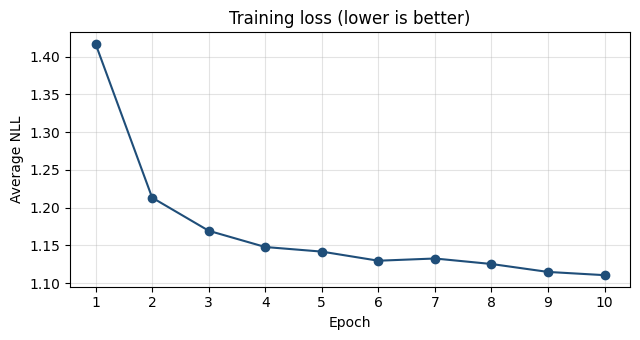

In [24]:
import matplotlib.pyplot as plt

if not training_completed or not epoch_loss_history:
    print("Run the training cell successfully first to plot loss.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    epochs_axis = np.arange(1, len(epoch_loss_history) + 1)
    ax.plot(epochs_axis, epoch_loss_history, "o-", color="#1f4e79", linewidth=1.5, markersize=6)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average NLL")
    ax.set_title("Training loss (lower is better)")
    ax.grid(True, alpha=0.35)
    ax.set_xticks(epochs_axis)
    plt.tight_layout()
    plt.show()


NLL on this batch (eval, training=False): 1.0856


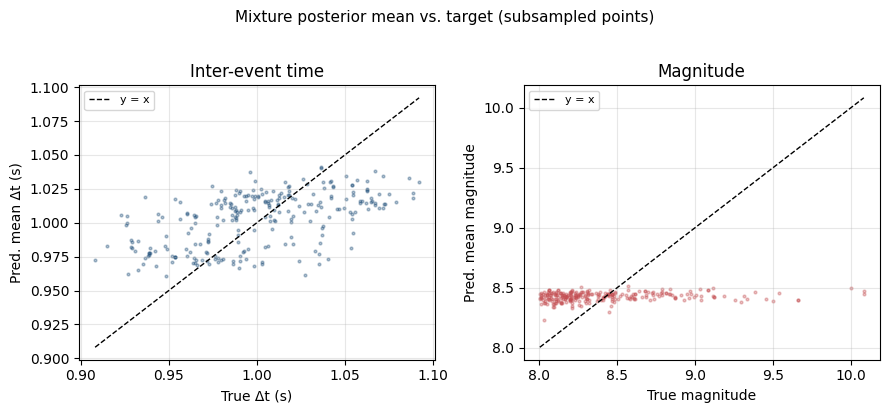

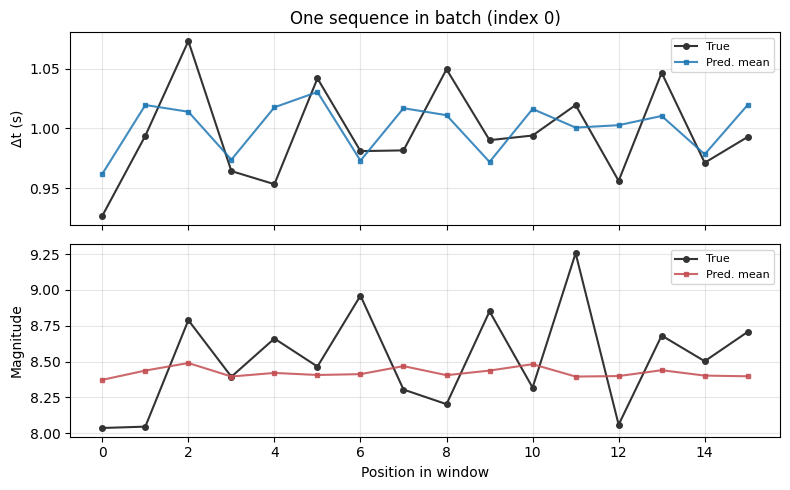

In [25]:
def mixture_expected(pi, mu):
    return tf.reduce_sum(pi * mu, axis=-1)


def denorm_sequences(x, stats):
    x = np.asarray(x, dtype=np.float64)
    out = np.empty_like(x)
    out[..., 0] = x[..., 0] * stats["dt_std"] + stats["dt_mean"]
    out[..., 1] = x[..., 1] * stats["mag_std"] + stats["mag_mean"]
    return out


if not training_completed:
    print("Run the training cell successfully first.")
else:
    batch_x, batch_y = next(iter(dataset))
    pi, mu, sigma = model(batch_x, training=False)
    pred_mean = mixture_expected(pi, mu)

    batch_nll = float(mdn_loss_function(pi, mu, sigma, batch_y))
    print(f"NLL on this batch (eval, training=False): {batch_nll:.4f}")

    y_np = batch_y.numpy()
    p_np = pred_mean.numpy()
    flat_y = y_np.reshape(-1, 2)
    flat_p = p_np.reshape(-1, 2)

    rng = np.random.default_rng(42)
    n_scatter = min(4000, len(flat_y))
    ix = rng.choice(len(flat_y), size=n_scatter, replace=False)
    y_d = denorm_sequences(flat_y[ix], norm_stats)
    p_d = denorm_sequences(flat_p[ix], norm_stats)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    lims_dt = [
        min(y_d[:, 0].min(), p_d[:, 0].min()),
        max(y_d[:, 0].max(), p_d[:, 0].max()),
    ]
    lims_m = [
        min(y_d[:, 1].min(), p_d[:, 1].min()),
        max(y_d[:, 1].max(), p_d[:, 1].max()),
    ]
    axes[0].scatter(y_d[:, 0], p_d[:, 0], s=4, alpha=0.35, c="#1f4e79")
    axes[0].plot(lims_dt, lims_dt, "k--", linewidth=1, label="y = x")
    axes[0].set_xlabel("True Δt (s)")
    axes[0].set_ylabel("Pred. mean Δt (s)")
    axes[0].set_title("Inter-event time")
    axes[0].legend(loc="upper left", fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(y_d[:, 1], p_d[:, 1], s=4, alpha=0.35, c="#c44e52")
    axes[1].plot(lims_m, lims_m, "k--", linewidth=1, label="y = x")
    axes[1].set_xlabel("True magnitude")
    axes[1].set_ylabel("Pred. mean magnitude")
    axes[1].set_title("Magnitude")
    axes[1].legend(loc="upper left", fontsize=8)
    axes[1].grid(True, alpha=0.3)
    plt.suptitle("Mixture posterior mean vs. target (subsampled points)", y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()

    sample_idx = 0
    t_axis = np.arange(y_np.shape[1])
    y0 = denorm_sequences(y_np[sample_idx : sample_idx + 1], norm_stats)[0]
    p0 = denorm_sequences(p_np[sample_idx : sample_idx + 1], norm_stats)[0]

    fig2, axes2 = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes2[0].plot(t_axis, y0[:, 0], "o-", label="True", color="#333", markersize=4)
    axes2[0].plot(t_axis, p0[:, 0], "s-", label="Pred. mean", color="#1f77b4", markersize=3, alpha=0.85)
    axes2[0].set_ylabel("Δt (s)")
    axes2[0].set_title(f"One sequence in batch (index {sample_idx})")
    axes2[0].legend(loc="upper right", fontsize=8)
    axes2[0].grid(True, alpha=0.3)

    axes2[1].plot(t_axis, y0[:, 1], "o-", label="True", color="#333", markersize=4)
    axes2[1].plot(t_axis, p0[:, 1], "s-", label="Pred. mean", color="#c44e52", markersize=3, alpha=0.85)
    axes2[1].set_xlabel("Position in window")
    axes2[1].set_ylabel("Magnitude")
    axes2[1].legend(loc="upper right", fontsize=8)
    axes2[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
